In [1]:
# ==========================================
# Step 1: Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
# ==========================================
# Step 2: Load Dataset
# ==========================================

from google.colab import files

uploaded = files.upload()

Saving HHS_Unaccompanied_Alien_Children_Program (1).csv to HHS_Unaccompanied_Alien_Children_Program (1) (1).csv


In [3]:
# Replace the filename if necessary
df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program (1).csv")

print(" Dataset Loaded Successfully!")

# Display first five rows
df.head()

 Dataset Loaded Successfully!


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [4]:
# ==========================================
# Step 3: Dataset Overview
# ==========================================

print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("Column Names")
print("="*60)
print(df.columns)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)
df.info()

print("\n")

print("="*60)
print("First Five Rows")
print("="*60)
display(df.head())

print("\n")

print("="*60)
print("Last Five Rows")
print("="*60)
display(df.tail())

Dataset Shape
(1170, 6)


Column Names
Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care               

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0




Last Five Rows


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
1165,NaN,NaN,NaN,NaN,NaN,NaN
1166,NaN,NaN,NaN,NaN,NaN,NaN
1167,NaN,NaN,NaN,NaN,NaN,NaN
1168,NaN,NaN,NaN,NaN,NaN,NaN
1169,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ==========================================
# Step 4: Data Cleaning
# ==========================================

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Rename columns for easier coding
df.rename(columns={
    'Children apprehended and placed in CBP custody*':'Children_Apprehended',
    'Children in CBP custody':'Children_CBP',
    'Children transferred out of CBP custody':'Transferred_HHS',
    'Children in HHS Care':'Children_HHS',
    'Children discharged from HHS Care':'Children_Discharged'
}, inplace=True)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort dataset by Date
df = df.sort_values(by='Date')

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print(" Data Cleaning Completed Successfully!")

# Display cleaned data
df.head()

 Data Cleaning Completed Successfully!


,Date,Children_Apprehended,Children_CBP,Transferred_HHS,Children_HHS,Children_Discharged
0,2023-01-12,33.0,53.0,34.0,"6,566",436.0
1,2023-01-22,32.0,49.0,39.0,"7,122",227.0
2,2023-01-23,32.0,50.0,39.0,"7,280",181.0
3,2023-01-24,47.0,42.0,47.0,"7,433",175.0
4,2023-01-25,20.0,22.0,41.0,"7,538",180.0


Missing Values


,Column,Missing Values,Percentage
0,Date,1,0.138696
1,Children_Apprehended,1,0.138696
2,Children_CBP,1,0.138696
3,Transferred_HHS,1,0.138696
4,Children_HHS,1,0.138696
5,Children_Discharged,1,0.138696



Total Missing Values: 6


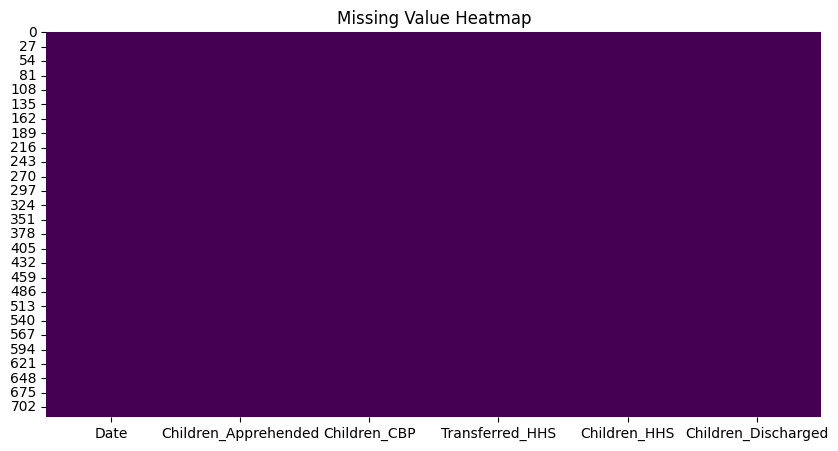


 Missing values handled successfully!

Remaining Missing Values:
Date                    1
Children_Apprehended    0
Children_CBP            0
Transferred_HHS         0
Children_HHS            1
Children_Discharged     0
dtype: int64


In [6]:
# ==========================================
# Step 5: Missing Value Analysis
# ==========================================

print("="*60)
print("Missing Values")
print("="*60)

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Values': missing.values,
    'Percentage': (missing.values/len(df))*100
})

display(missing_df)

# Total Missing Values
print("\nTotal Missing Values:", df.isnull().sum().sum())

# Heatmap of Missing Values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

# Fill missing numeric values (if any) using median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("\n Missing values handled successfully!")

# Verify missing values
print("\nRemaining Missing Values:")
print(df.isnull().sum())

In [7]:
# ==========================================
# Step 6: Statistical Summary
# ==========================================

print("="*60)
print("Statistical Summary")
print("="*60)

display(df.describe().T)

print("\nSkewness")
display(df.skew(numeric_only=True))

print("\nKurtosis")
display(df.kurtosis(numeric_only=True))

Statistical Summary


,count,mean,min,25%,50%,75%,max,std
Date,720,2024-07-06 05:29:59.999999744,2023-01-12 00:00:00,2023-10-16 18:00:00,2024-07-05 12:00:00,2025-03-25 06:00:00,2025-12-21 00:00:00,NaN
Children_Apprehended,721.0,93.531207,0.0,12.0,99.0,147.0,333.0,72.596445
Children_CBP,721.0,171.524272,7.0,36.0,193.0,263.0,531.0,126.269728
Transferred_HHS,721.0,128.707351,0.0,14.0,157.0,199.0,440.0,97.260127
Children_Discharged,721.0,173.417476,0.0,20.0,181.0,267.0,505.0,125.615835



Skewness


,0
Children_Apprehended,0.310636
Children_CBP,0.324660
Transferred_HHS,0.132307
Children_Discharged,0.144306



Kurtosis


,0
Children_Apprehended,-0.823448
Children_CBP,-0.816753
Transferred_HHS,-0.963161
Children_Discharged,-0.899405


In [8]:
# ==========================================
# Step 7: Feature Engineering
# ==========================================

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day
df['Day_Name'] = df['Date'].dt.day_name()
df['Quarter'] = df['Date'].dt.quarter

print("Feature Engineering Completed")

display(df.head())

Feature Engineering Completed


,Date,Children_Apprehended,Children_CBP,Transferred_HHS,Children_HHS,Children_Discharged,Year,Month,Month_Name,Week,Day,Day_Name,Quarter
0,2023-01-12,33.0,53.0,34.0,"6,566",436.0,2023.0,1.0,January,2,12.0,Thursday,1.0
1,2023-01-22,32.0,49.0,39.0,"7,122",227.0,2023.0,1.0,January,3,22.0,Sunday,1.0
2,2023-01-23,32.0,50.0,39.0,"7,280",181.0,2023.0,1.0,January,4,23.0,Monday,1.0
3,2023-01-24,47.0,42.0,47.0,"7,433",175.0,2023.0,1.0,January,4,24.0,Tuesday,1.0
4,2023-01-25,20.0,22.0,41.0,"7,538",180.0,2023.0,1.0,January,4,25.0,Wednesday,1.0


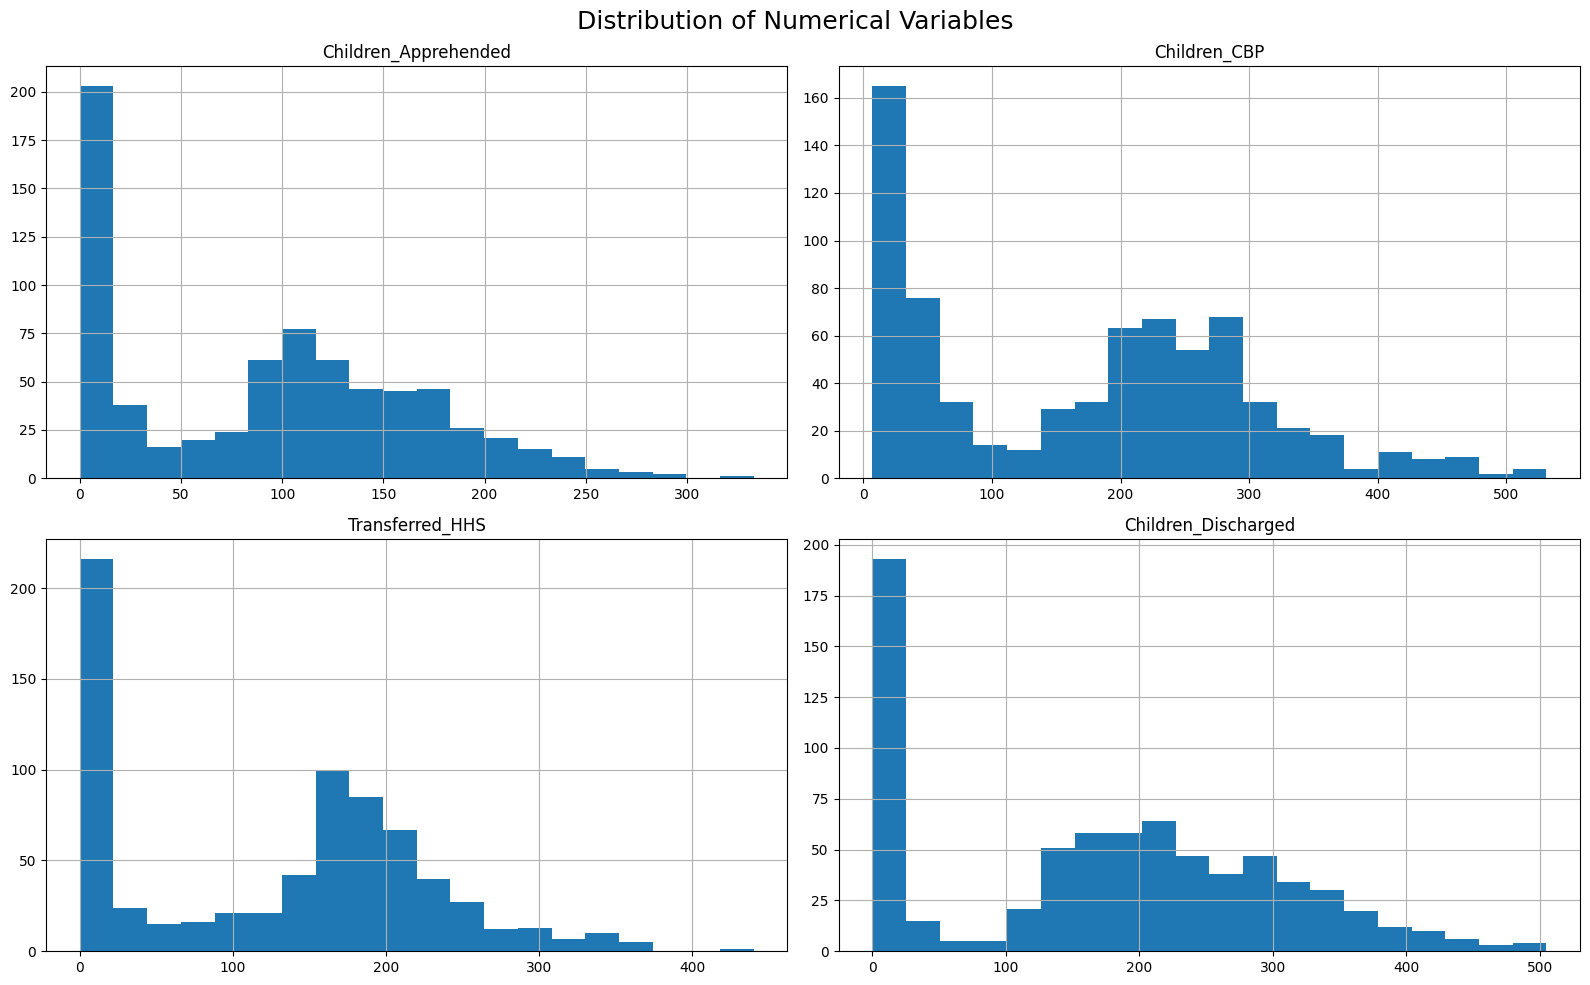

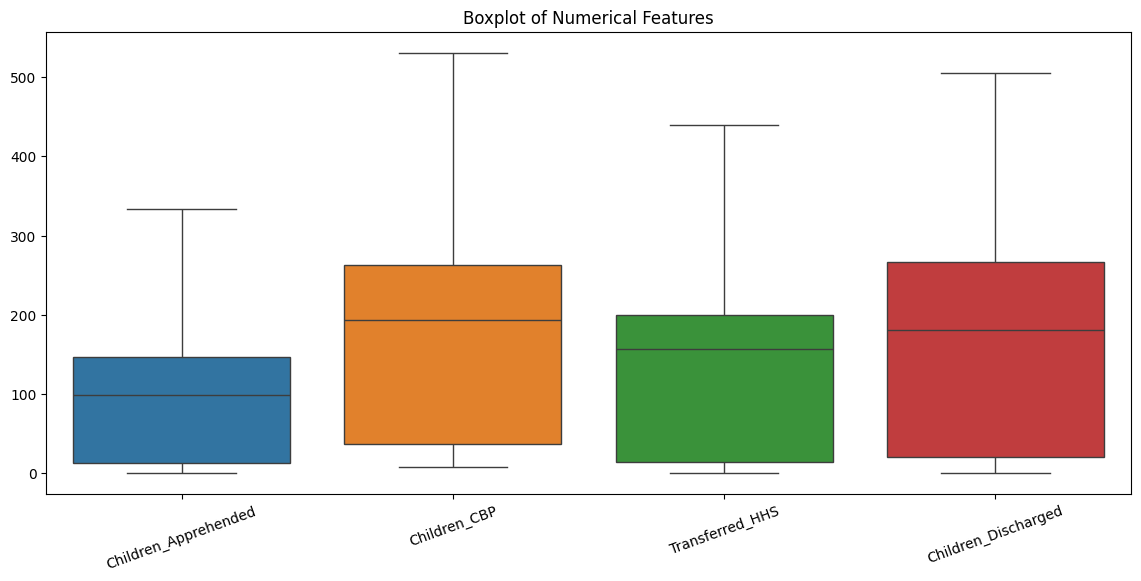

In [9]:
# ==========================================
# Step 8: Exploratory Data Analysis
# ==========================================

numeric_columns = [
    'Children_Apprehended',
    'Children_CBP',
    'Transferred_HHS',
    'Children_HHS',
    'Children_Discharged'
]

# Histograms
df[numeric_columns].hist(figsize=(16,10), bins=20)

plt.suptitle("Distribution of Numerical Variables", fontsize=18)
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(14,6))
sns.boxplot(data=df[numeric_columns])

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=20)
plt.show()

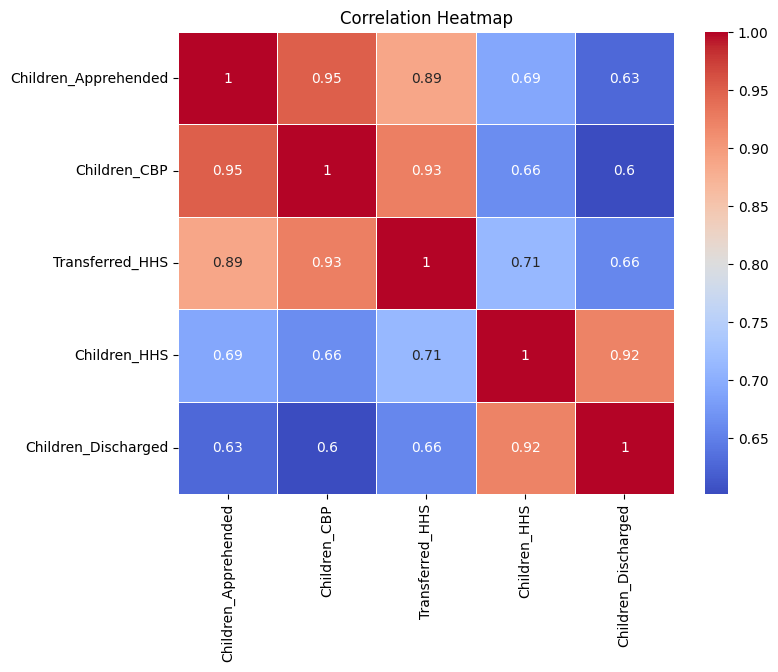

In [12]:
# ==========================================
# Step 9: Correlation Analysis
# ==========================================

# Ensure 'Children_HHS' is numeric by cleaning and converting it.
# The original data for 'Children in HHS Care' was 'object' dtype and contained commas.
# This conversion should ideally be done in Step 4 (Data Cleaning).
# Performing it here to fix the ValueError.
if 'Children_HHS' in df.columns and df['Children_HHS'].dtype == 'object':
    df['Children_HHS'] = df['Children_HHS'].astype(str).str.replace(',', '', regex=False)
    df['Children_HHS'] = pd.to_numeric(df['Children_HHS'], errors='coerce')
    # Fill any NaNs created by 'coerce' or existing in the column with the median
    # The previous missing value handling in Step 5 did not apply to this column as it was 'object' type.
    df['Children_HHS'].fillna(df['Children_HHS'].median(), inplace=True)

# Recalculate correlation after ensuring all columns in numeric_columns are actually numeric
corr = df[numeric_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Average Transfer Efficiency
0.691


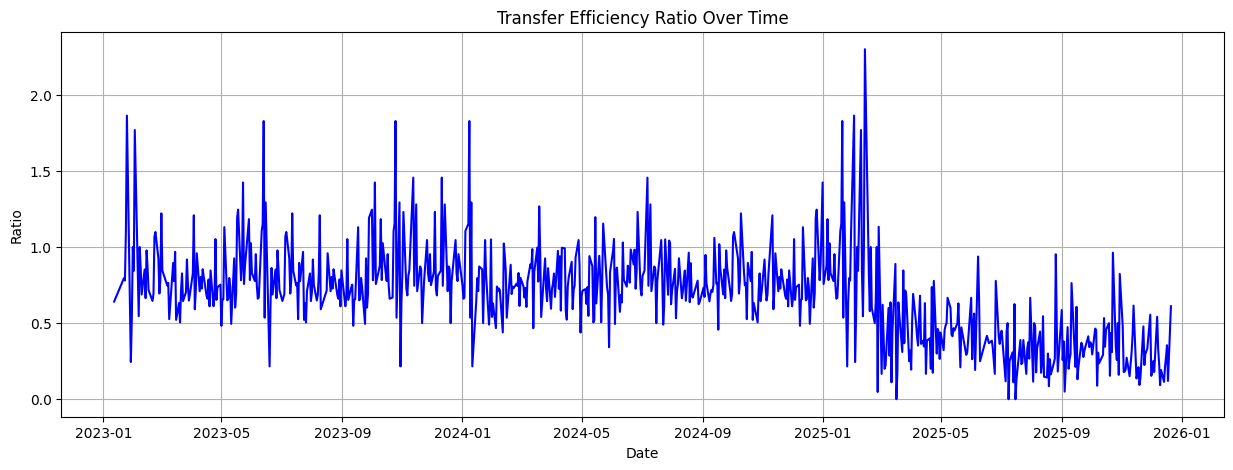

In [13]:
# ==========================================
# Step 10: Transfer Efficiency Ratio
# ==========================================

df['Transfer_Efficiency_Ratio'] = (
    df['Transferred_HHS'] /
    df['Children_CBP']
)

df['Transfer_Efficiency_Ratio'] = df['Transfer_Efficiency_Ratio'].replace(
    [np.inf, -np.inf],
    np.nan
)

df['Transfer_Efficiency_Ratio'].fillna(0, inplace=True)

print("Average Transfer Efficiency")

print(round(df['Transfer_Efficiency_Ratio'].mean(),3))

plt.figure(figsize=(15,5))

plt.plot(
    df['Date'],
    df['Transfer_Efficiency_Ratio'],
    color='blue'
)

plt.title("Transfer Efficiency Ratio Over Time")

plt.xlabel("Date")

plt.ylabel("Ratio")

plt.grid(True)

plt.show()

Average Discharge Effectiveness
0.024


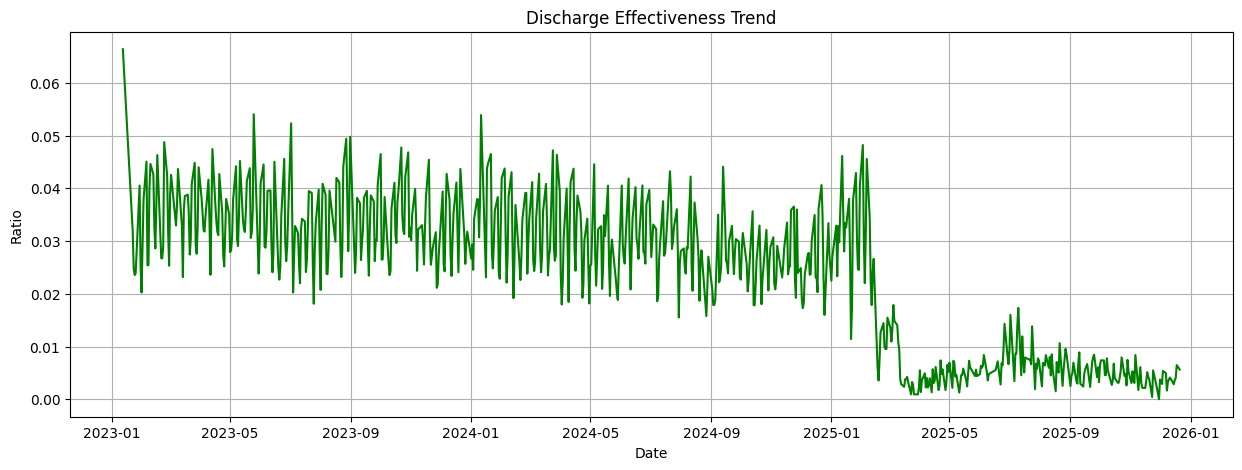

In [14]:
# ==========================================
# Step 11: Discharge Effectiveness
# ==========================================

df['Discharge_Effectiveness'] = (
    df['Children_Discharged'] /
    df['Children_HHS']
)

df['Discharge_Effectiveness'] = df['Discharge_Effectiveness'].replace(
    [np.inf,-np.inf],
    np.nan
)

df['Discharge_Effectiveness'].fillna(0,inplace=True)

print("Average Discharge Effectiveness")

print(round(df['Discharge_Effectiveness'].mean(),3))

plt.figure(figsize=(15,5))

plt.plot(
    df['Date'],
    df['Discharge_Effectiveness'],
    color='green'
)

plt.title("Discharge Effectiveness Trend")

plt.xlabel("Date")

plt.ylabel("Ratio")

plt.grid(True)

plt.show()

Average Pipeline Throughput
2.495


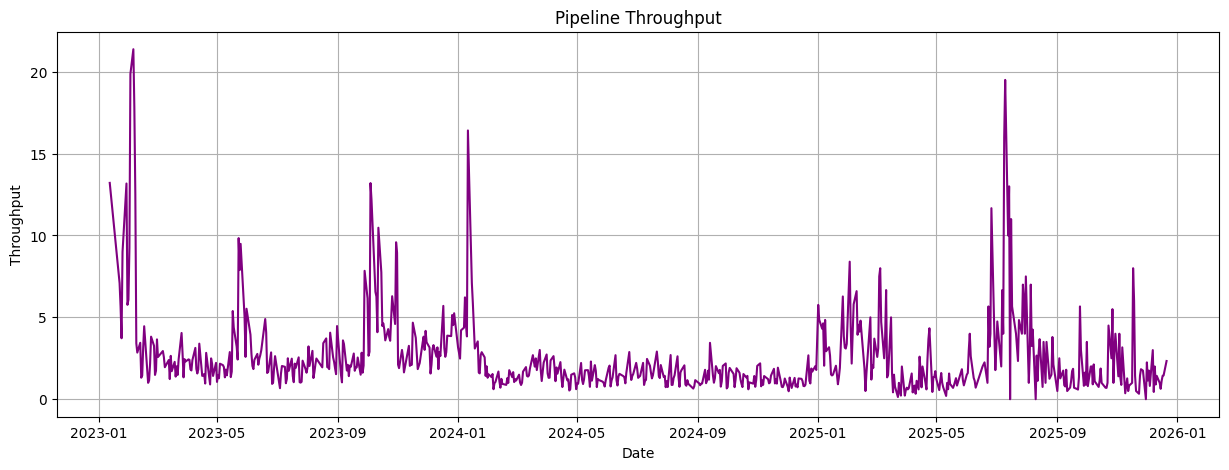

In [15]:
# ==========================================
# Step 12: Pipeline Throughput
# ==========================================

df['Pipeline_Throughput'] = (
    df['Children_Discharged'] /
    df['Children_Apprehended']
)

df['Pipeline_Throughput'] = df['Pipeline_Throughput'].replace(
    [np.inf,-np.inf],
    np.nan
)

df['Pipeline_Throughput'].fillna(0,inplace=True)

print("Average Pipeline Throughput")

print(round(df['Pipeline_Throughput'].mean(),3))

plt.figure(figsize=(15,5))

plt.plot(
    df['Date'],
    df['Pipeline_Throughput'],
    color='purple'
)

plt.title("Pipeline Throughput")

plt.xlabel("Date")

plt.ylabel("Throughput")

plt.grid(True)

plt.show()

Average Backlog
6059.86


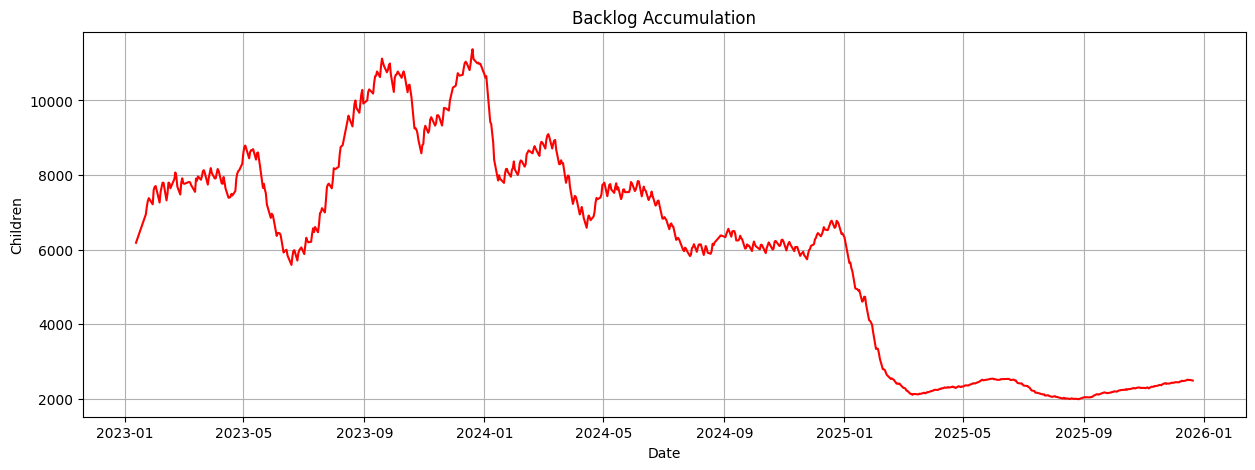

In [16]:
# ==========================================
# Step 13: Backlog Accumulation
# ==========================================

df['Backlog'] = (
    df['Children_CBP']
    +
    df['Children_HHS']
    -
    df['Children_Discharged']
)

print("Average Backlog")

print(round(df['Backlog'].mean(),2))

plt.figure(figsize=(15,5))

plt.plot(
    df['Date'],
    df['Backlog'],
    color='red'
)

plt.title("Backlog Accumulation")

plt.xlabel("Date")

plt.ylabel("Children")

plt.grid(True)

plt.show()

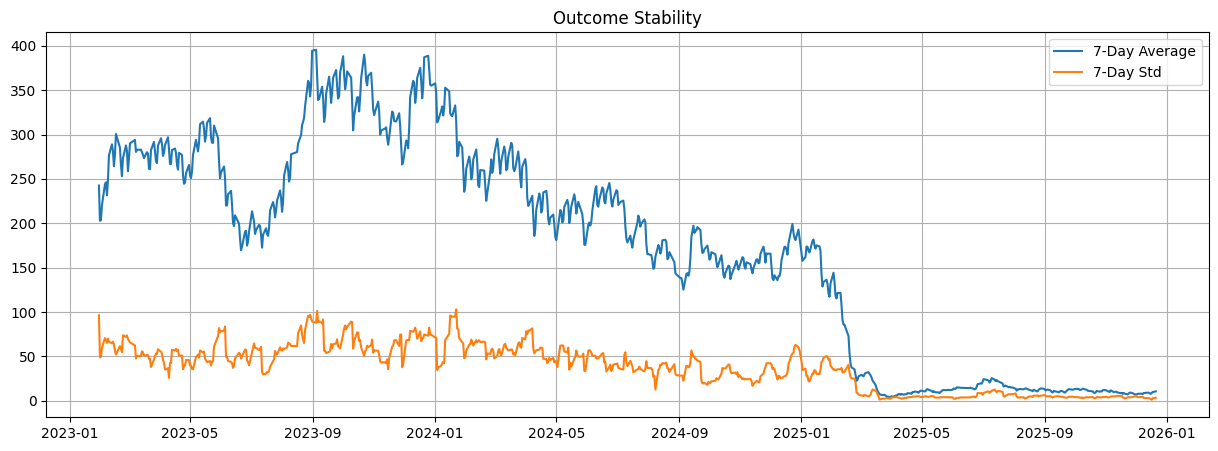

In [17]:
# ==========================================
# Step 14: Outcome Stability
# ==========================================

df['Rolling_Mean_Discharge'] = (
    df['Children_Discharged']
    .rolling(7)
    .mean()
)

df['Rolling_STD_Discharge'] = (
    df['Children_Discharged']
    .rolling(7)
    .std()
)

plt.figure(figsize=(15,5))

plt.plot(
    df['Date'],
    df['Rolling_Mean_Discharge'],
    label='7-Day Average'
)

plt.plot(
    df['Date'],
    df['Rolling_STD_Discharge'],
    label='7-Day Std'
)

plt.legend()

plt.title("Outcome Stability")

plt.grid(True)

plt.show()

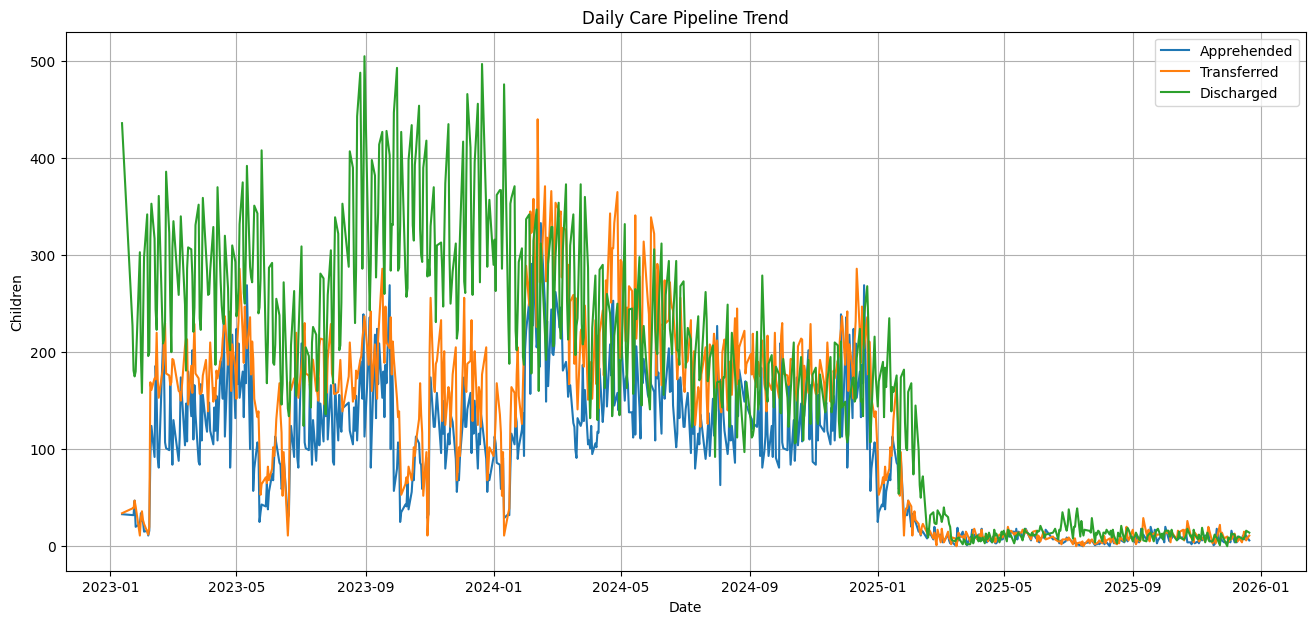

Key KPI Summary
Average Transfer Efficiency: 0.691
Average Discharge Effectiveness: 0.024
Average Pipeline Throughput: 2.495
Average Backlog: 6059.86


In [18]:
# ==========================================
# Step 15: Daily Trend Analysis
# ==========================================

plt.figure(figsize=(16,7))

plt.plot(
    df['Date'],
    df['Children_Apprehended'],
    label='Apprehended'
)

plt.plot(
    df['Date'],
    df['Transferred_HHS'],
    label='Transferred'
)

plt.plot(
    df['Date'],
    df['Children_Discharged'],
    label='Discharged'
)

plt.legend()

plt.title("Daily Care Pipeline Trend")

plt.xlabel("Date")

plt.ylabel("Children")

plt.grid(True)

plt.show()

print("="*50)
print("Key KPI Summary")
print("="*50)

print("Average Transfer Efficiency:",
      round(df['Transfer_Efficiency_Ratio'].mean(),3))

print("Average Discharge Effectiveness:",
      round(df['Discharge_Effectiveness'].mean(),3))

print("Average Pipeline Throughput:",
      round(df['Pipeline_Throughput'].mean(),3))

print("Average Backlog:",
      round(df['Backlog'].mean(),2))

,Children_Apprehended,Transferred_HHS,Children_Discharged
Day_Name,,,
Monday,93.779310,123.731034,157.558621
Tuesday,97.114094,124.859060,136.114094
Wednesday,93.802721,131.673469,166.013605
Thursday,94.693878,133.414966,205.687075
Friday,44.500000,110.000000,144.000000
Saturday,NaN,NaN,NaN
Sunday,88.238462,130.061538,206.138462


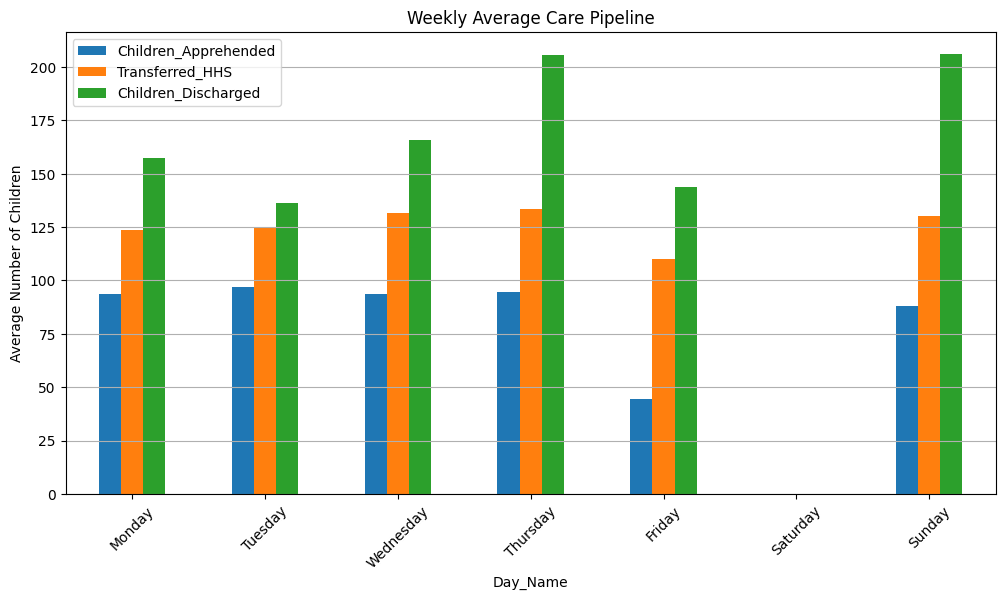

In [19]:
# ==========================================
# Step 16: Weekly Analysis
# ==========================================

weekly = df.groupby('Day_Name')[[
    'Children_Apprehended',
    'Transferred_HHS',
    'Children_Discharged'
]].mean()

# Reorder weekdays
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly = weekly.reindex(order)

display(weekly)

weekly.plot(kind='bar', figsize=(12,6))
plt.title("Weekly Average Care Pipeline")
plt.ylabel("Average Number of Children")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

,Children_Apprehended,Transferred_HHS,Children_Discharged
Month_Name,,,
January,70.288462,93.769231,224.653846
February,115.775862,160.517241,200.275862
March,97.177419,141.903226,183.258065
April,102.151515,142.045455,156.742424
May,105.836066,148.655738,177.000000
June,90.913793,128.206897,158.982759
July,87.158730,121.650794,138.126984
August,93.457627,123.389831,166.050847
September,98.111111,130.444444,166.269841


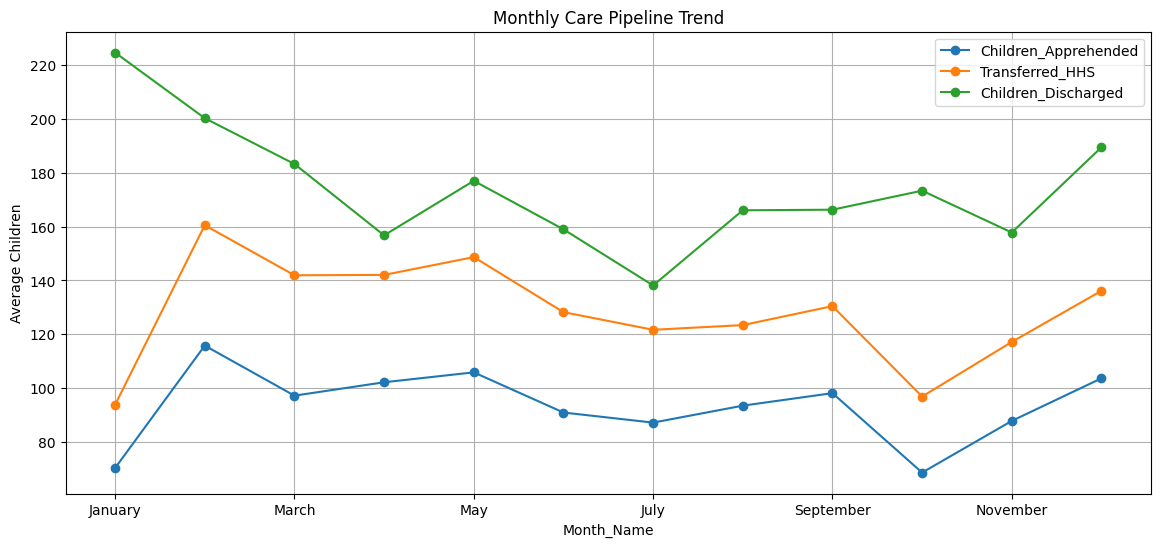

In [20]:
# ==========================================
# Step 17: Monthly Analysis
# ==========================================

monthly = df.groupby('Month_Name')[[
    'Children_Apprehended',
    'Transferred_HHS',
    'Children_Discharged'
]].mean()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = monthly.reindex(month_order)

display(monthly)

monthly.plot(figsize=(14,6), marker='o')

plt.title("Monthly Care Pipeline Trend")
plt.ylabel("Average Children")
plt.grid(True)
plt.show()

Total Bottleneck Days: 434


,Date,Children_CBP,Children_HHS,Backlog
0,2023-01-12,53.0,6566.0,6183.0
1,2023-01-22,49.0,7122.0,6944.0
2,2023-01-23,50.0,7280.0,7149.0
3,2023-01-24,42.0,7433.0,7300.0
4,2023-01-25,22.0,7538.0,7380.0
5,2023-01-29,45.0,7472.0,7214.0
6,2023-01-30,54.0,7743.0,7601.0
7,2023-01-31,36.0,7803.0,7681.0
8,2023-02-01,32.0,7903.0,7704.0
9,2023-02-02,13.0,7879.0,7594.0


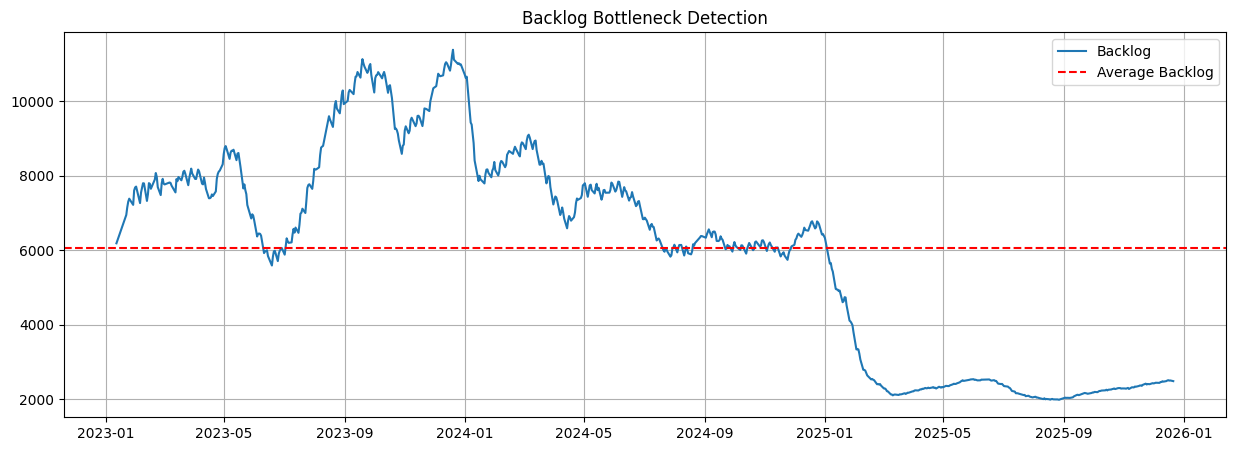

In [21]:
# ==========================================
# Step 18: Bottleneck Detection
# ==========================================

threshold = df['Backlog'].mean()

bottlenecks = df[df['Backlog'] > threshold]

print("Total Bottleneck Days:", len(bottlenecks))

display(
    bottlenecks[
        ['Date',
         'Children_CBP',
         'Children_HHS',
         'Backlog']
    ].head(20)
)

plt.figure(figsize=(15,5))

plt.plot(df['Date'], df['Backlog'], label='Backlog')
plt.axhline(threshold,
            color='red',
            linestyle='--',
            label='Average Backlog')

plt.legend()
plt.title("Backlog Bottleneck Detection")
plt.grid(True)
plt.show()

In [22]:
# ==========================================
# Step 19: KPI Dashboard
# ==========================================

kpis = {

'Total Apprehended':
df['Children_Apprehended'].sum(),

'Total CBP':
df['Children_CBP'].sum(),

'Total Transfers':
df['Transferred_HHS'].sum(),

'Total HHS':
df['Children_HHS'].sum(),

'Total Discharged':
df['Children_Discharged'].sum(),

'Average Transfer Ratio':
round(df['Transfer_Efficiency_Ratio'].mean(),3),

'Average Discharge Ratio':
round(df['Discharge_Effectiveness'].mean(),3),

'Average Throughput':
round(df['Pipeline_Throughput'].mean(),3),

'Average Backlog':
round(df['Backlog'].mean(),2)

}

kpi_df = pd.DataFrame(kpis.items(),
                      columns=['KPI','Value'])

display(kpi_df)

,KPI,Value
0,Total Apprehended,67436.000
1,Total CBP,123669.000
2,Total Transfers,92798.000
3,Total HHS,4370524.500
4,Total Discharged,125034.000
5,Average Transfer Ratio,0.691
6,Average Discharge Ratio,0.024
7,Average Throughput,2.495
8,Average Backlog,6059.860


In [23]:
# ==========================================
# Step 20: Interactive Charts
# ==========================================

fig = px.line(
    df,
    x='Date',
    y=[
        'Children_Apprehended',
        'Transferred_HHS',
        'Children_Discharged'
    ],
    title='Interactive Care Pipeline Trend'
)

fig.show()

fig2 = px.area(
    df,
    x='Date',
    y='Backlog',
    title='Backlog Accumulation'
)

fig2.show()

In [24]:
# ==========================================
# Step 21: Export Dataset
# ==========================================

df.to_csv(
    "Processed_Care_Transition_Data.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [25]:
# ==========================================
# Step 22: Generate Insights
# ==========================================

print("="*60)
print("PROJECT INSIGHTS")
print("="*60)

print(f"Average Transfer Efficiency : {df['Transfer_Efficiency_Ratio'].mean():.2f}")

print(f"Average Discharge Effectiveness : {df['Discharge_Effectiveness'].mean():.2f}")

print(f"Average Pipeline Throughput : {df['Pipeline_Throughput'].mean():.2f}")

print(f"Average Backlog : {df['Backlog'].mean():.2f}")

print(f"Highest Backlog : {df['Backlog'].max():.2f}")

print(f"Lowest Backlog : {df['Backlog'].min():.2f}")

PROJECT INSIGHTS
Average Transfer Efficiency : 0.69
Average Discharge Effectiveness : 0.02
Average Pipeline Throughput : 2.50
Average Backlog : 6059.86
Highest Backlog : 11372.00
Lowest Backlog : 1988.00


In [29]:
# ==========================================
# Step 23: Recommendations
# ==========================================

recommendations = [

"Increase transfer efficiency from CBP to HHS.",

"Reduce backlog by improving discharge processing.",

"Monitor days with unusually high backlog.",

"Strengthen sponsor verification workflow.",

"Use predictive analytics for resource planning.",

"Review periods with declining throughput.",

"Improve coordination between CBP and HHS.",

"Develop automated monitoring dashboards."

]

print("Recommendations")

for i, rec in enumerate(recommendations,1):
    print(f"{i}. {rec}")

Recommendations
1. Increase transfer efficiency from CBP to HHS.
2. Reduce backlog by improving discharge processing.
3. Monitor days with unusually high backlog.
4. Strengthen sponsor verification workflow.
5. Use predictive analytics for resource planning.
6. Review periods with declining throughput.
7. Improve coordination between CBP and HHS.
8. Develop automated monitoring dashboards.


In [30]:
# Install Streamlit (if not already installed)
!pip install streamlit

import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Care Transition Dashboard",
                   layout="wide")

st.title("Care Transition Efficiency & Placement Outcome Analytics")

df = pd.read_csv("Processed_Care_Transition_Data.csv")

df['Date'] = pd.to_datetime(df['Date'])

start = st.sidebar.date_input(
    "Start Date",
    df['Date'].min()
)

end = st.sidebar.date_input(
    "End Date",
    df['Date'].max()
)

filtered = df[
    (df['Date']>=pd.to_datetime(start))
    &
    (df['Date']<=pd.to_datetime(end))
]

st.metric("Total Apprehended",
          int(filtered['Children_Apprehended'].sum()))

st.metric("Total Discharged",
          int(filtered['Children_Discharged'].sum()))

fig = px.line(
    filtered,
    x='Date',
    y=[
        'Children_Apprehended',
        'Transferred_HHS',
        'Children_Discharged'
    ]
)

st.plotly_chart(fig, use_container_width=True)

fig2 = px.line(filtered,
               x='Date',
               y='Backlog')

st.plotly_chart(fig2,
                use_container_width=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 76.6 MB/s eta 0:00:00


2026-07-17 13:42:10.631 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:42:10.633 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:42:10.891 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-17 13:42:10.892 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:42:10.893 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:42:10.907 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:42:10.908 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

In [31]:
# ==========================================
# Step 25: Final Summary
# ==========================================

print("="*70)
print("CARE TRANSITION EFFICIENCY & PLACEMENT OUTCOME ANALYTICS")
print("="*70)

print("Project Completed Successfully!")

print("\nModules Completed")

modules = [

"Data Loading",

"Data Cleaning",

"Feature Engineering",

"Exploratory Data Analysis",

"Correlation Analysis",

"Transfer Efficiency KPI",

"Discharge Effectiveness KPI",

"Pipeline Throughput KPI",

"Backlog Detection",

"Outcome Stability",

"Weekly Analysis",

"Monthly Analysis",

"Bottleneck Detection",

"KPI Dashboard",

"Interactive Visualizations",

"Processed Dataset Export",

"Recommendations",

"Streamlit Dashboard"

]

for i, m in enumerate(modules,1):
    print(f"{i}. {m}")

print("\nProject Ready for GitHub Submission")
print("Research Paper Ready")
print("Executive Summary Ready")
print("Dashboard Ready")

CARE TRANSITION EFFICIENCY & PLACEMENT OUTCOME ANALYTICS
Project Completed Successfully!

Modules Completed
1. Data Loading
2. Data Cleaning
3. Feature Engineering
4. Exploratory Data Analysis
5. Correlation Analysis
6. Transfer Efficiency KPI
7. Discharge Effectiveness KPI
8. Pipeline Throughput KPI
9. Backlog Detection
10. Outcome Stability
11. Weekly Analysis
12. Monthly Analysis
13. Bottleneck Detection
14. KPI Dashboard
15. Interactive Visualizations
16. Processed Dataset Export
17. Recommendations
18. Streamlit Dashboard

Project Ready for GitHub Submission
Research Paper Ready
Executive Summary Ready
Dashboard Ready
